In [1]:
# uci_har_prototype.py
# UCI HAR baseline prototype - 6-class model for domain validation only.

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

from google.colab import drive

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# Confirm project folder accessibility in My Drive
#print(os.listdir('/content/drive/My Drive/AG/FH/study/AI_IoT/node/milestone2/UCI-HAR_Dataset'))



Mounted at /content/drive


In [3]:
# Declare project home directory
project_path = "/content/drive/My Drive/AG/FH/study/AI_IoT/node/milestone2"
os.makedirs(project_path, exist_ok=True)

# Create output directory
os.makedirs(f"{project_path}/output", exist_ok=True)

In [4]:
# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

TARGET_NAMES = ["WALKING", "WALKING_UP", "WALKING_DOWN", "SITTING", "STANDING", "LAYING"]
NUM_CLASSES  = 6

In [5]:
# ── Data loading ──────────────────────────────────────────────────────────────
def load_uci_har_raw(data_path=f"{project_path}/UCI-HAR_Dataset"):
    acc_axes  = ["body_acc_x",  "body_acc_y",  "body_acc_z"]
    gyro_axes = ["body_gyro_x", "body_gyro_y", "body_gyro_z"]

    def _load_split(split):
        arrays = []
        for name in acc_axes + gyro_axes:
            path = f"{data_path}/{split}/InertialSignals/{name}_{split}.txt"
            arrays.append(np.loadtxt(path))
        return np.stack(arrays, axis=-1)

    X_train = _load_split("train")
    X_test  = _load_split("test")

    y_train = np.loadtxt(f"{data_path}/train/y_train.txt", dtype=int)
    y_test  = np.loadtxt(f"{data_path}/test/y_test.txt", dtype=int)

    y_train -= 1
    y_test  -= 1

    return X_train, y_train, X_test, y_test

In [6]:
# ── Feature extraction ────────────────────────────────────────────────────────
def extract_features_window(window):
    feats = []
    for axis in range(6):
        feats.append(np.mean(window[:, axis]))
        feats.append(np.std(window[:, axis]))
    for axis in range(6):
        feats.append(np.min(window[:, axis]))
        feats.append(np.max(window[:, axis]))

    feats.append(np.sum(np.abs(window[:, :3])) / window.shape[0])
    feats.append(np.sum(np.abs(window[:, 3:])) / window.shape[0])

    acc_mag = np.linalg.norm(window[:, :3], axis=1)
    feats.append(np.mean(acc_mag))
    feats.append(np.std(acc_mag))

    return np.array(feats)

In [7]:
# ── Main ──────────────────────────────────────────────────────────────────────
X_train_raw, y_train, X_test_raw, y_test = load_uci_har_raw()

X_train_feat = np.array([extract_features_window(w) for w in X_train_raw])
X_test_feat  = np.array([extract_features_window(w) for w in X_test_raw])

print(f"Feature shape - train: {X_train_feat.shape}, test: {X_test_feat.shape}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_feat)
X_test_sc  = scaler.transform(X_test_feat)

model = models.Sequential([
    layers.Input(shape=(X_train_feat.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="uci_har_baseline")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_sc, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_sc, y_test),
    callbacks=[early_stop],
    verbose=1,
)

Feature shape - train: (7352, 28), test: (2947, 28)


Model: "uci_har_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,126 (4.40 KB)

 Trainable params: 1,126 (4.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4365 - loss: 1.1779 - val_accuracy: 0.5185 - val_loss: 1.0025
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5513 - loss: 0.9286 - val_accuracy: 0.5667 - val_loss: 0.8996
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5898 - loss: 0.8463 - val_accuracy: 0.5898 - val_loss: 0.8449
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6126 - loss: 0.7986 - val_accuracy: 0.6054 - val_loss: 0.8109
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6269 - loss: 0.7667 - val_accuracy: 0.6223 - val_loss: 0.7849
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6434 - loss: 0.7426 - val_accuracy: 0.6386 - val_loss: 0.7642
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6527 - loss: 0.7239 - val_accuracy: 0.6563 - val_loss: 0.7472
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6612 - loss: 0.7080 - val_accuracy: 0.

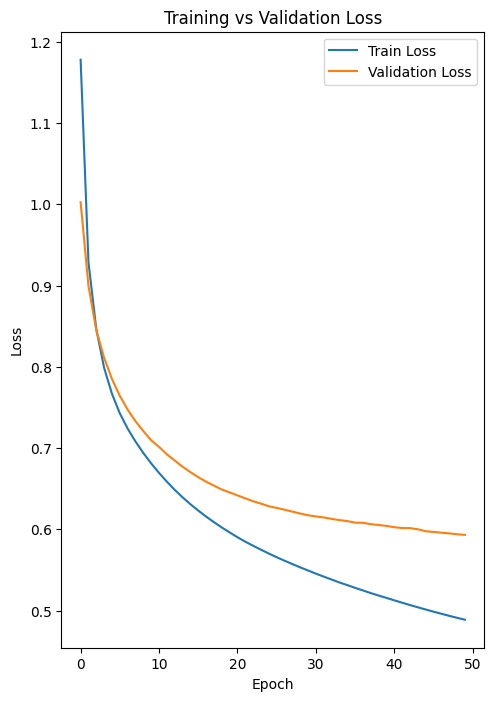

In [8]:
# ── Plot Training vs Validation Loss & Accuracy ───────────────────────────────
plt.figure(figsize=(12,8))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"{project_path}/output/training_validation_curves.png", dpi=150)
plt.show()

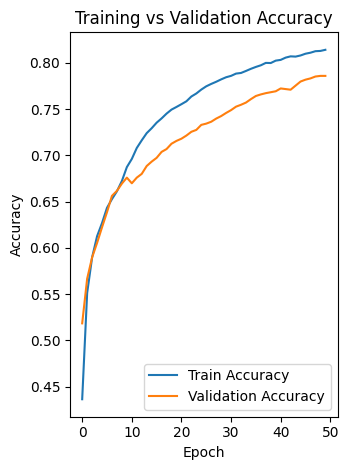

Saved training_curves.png


In [9]:
# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(f"{project_path}/output/training_curves.png", dpi=150)
plt.show()

print("Saved training_curves.png")



93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

              precision    recall  f1-score   support

     WALKING       0.86      0.85      0.85       496
  WALKING_UP       0.80      0.86      0.83       471
WALKING_DOWN       0.94      0.88      0.91       420
     SITTING       0.75      0.58      0.65       491
    STANDING       0.82      0.66      0.73       532
      LAYING       0.65      0.90      0.76       537

    accuracy                           0.79      2947
   macro avg       0.80      0.79      0.79      2947
weighted avg       0.80      0.79      0.78      2947



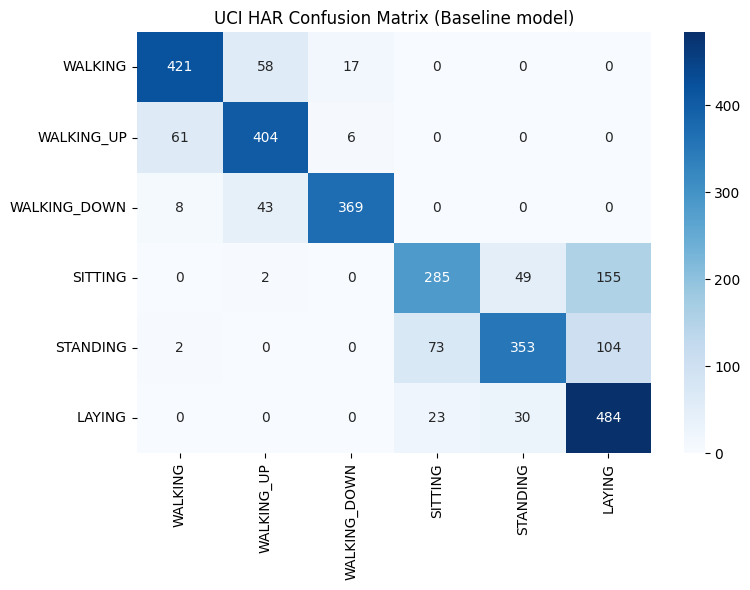

Saved uci_har_confusion_matrix.png


In [10]:

# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(X_test_sc), axis=1)

print("\n" + classification_report(y_test, y_pred, target_names=TARGET_NAMES))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=TARGET_NAMES,
            yticklabels=TARGET_NAMES,
            cmap="Blues")

plt.title("UCI HAR Confusion Matrix (Baseline model)")
plt.tight_layout()
plt.savefig(f"{project_path}/output/uci_har_confusion_matrix.png", dpi=150)
plt.show()

print("Saved uci_har_confusion_matrix.png")

In [11]:
# ── Save Model ────────────────────────────────────────────────────────────────
model.save(f"{project_path}/uci_har_baseline.keras")
print("Saved uci_har_baseline.keras")

Saved uci_har_baseline.keras
